## 前一条测试视频的结果（历史记录）

以下结果属于先前的测试视频，保存在 `results/test_video/`；不是当前 `jiayou_guoqing.mp4` 的分析结果。不把自动估计当成事实标签。

- **手工特征：** 246 行合并表（每种音频版本 82 个重叠窗口），每窗 62 个声学数值特征；见 `handcrafted_audio_vectors_all_stems.csv`。
- **Librosa：** `music_summary.csv` 中原始混音与 no_vocals 的估计节拍约 112.35 BPM、调性候选 G:maj；vocals 为约 53.83 BPM、D:min。分离 stem 结果差异很大，可能反映歌声/残留内容、算法误差或伪影；应试听核验，不代表音乐真有不同速度/调性。chroma DTW 的归一化累计代价是原始 vs vocals 0.056、原始 vs no_vocals 0.015；这是该特征和算法下的相似度线索，不是分离质量分数。
- **MERT：** `mert_v1_95m_embeddings.npy` 是 246 × 768 矩阵；索引 CSV 将每一行映射到 video_id、stem 和起止时间。
- **Basic Pitch：** 三个版本均已输出 note-event CSV 与 MIDI。CSV 每个事件含起止时间、MIDI 音高、力度及可变长度的 pitch-bend 序列；因此行列长度不固定，不要直接用普通 `pandas.read_csv` 假设每行只有固定列数。事件和 MIDI 是估计结果，应播放 MIDI 并与原音频对照。

建议先挑同一组时间片段试听三个 stem，并对照 MERT/Basic Pitch 结果。记录哪些 stem 清楚呈现目标音乐、哪些有讲话残留或分离伪影。当前单视频结果用于流程检查和提出假设，不能据此概括 Douyin 整体音频或做稳定跨视频聚类。

# Test video: jiayou_guoqing sample analysis

当前先分析用户上传的 `jiayou_guoqing.mp4`；不运行批量下载。记录样本来源与处理步骤，但不预先给视频内容或意图贴标签。

- 文件：[jiayou_guoqing.mp4](../video/jiayou_guoqing.mp4)
- 用途：当前单视频探索样本；不代表总体语料
- 注意：保留原视频；处理后的音频和结果写入独立目录，不覆盖源文件


## `jiayou_guoqing.mp4` — 初步音频分析结果

分析的是本地上传的短视频；本次跳过 URL 下载。视频约 21.03 秒，AAC 立体声音轨约 20.85 秒、44.1 kHz。项目内原视频副本为 `video/jiayou_guoqing.mp4`，SHA-256: `518a5f23cf2df375b8be58bfa7b45526c54bb6e8ef30f4af87cf3308c2781dba`。

- **输入与输出：** 音频已提取，并保留原混音和 Demucs `vocals` / `no_vocals` 两个估计 stem。`audio_manifest.csv` 中有 3 条记录。全部结果保存在 `results/jiayou_guoqing/`。
- **音质筛查：** 三个版本均为 44.1 kHz 立体声；削波比例和低于 RMS `0.0001` 的近静音帧比例均为 0。原混音平均 RMS 约 0.307、vocals 约 0.075、no_vocals 约 0.290。技术指标不能说明音乐/语音内容，也不能取代试听。
- **手工窗口特征：** 每个版本 9 个重叠窗口，每窗 5 秒、步长 2.5 秒，每窗 62 个数值特征；合并表共 27 行。约 21 秒的短片段样本很少，不适合据此训练或稳定聚类。
- **Librosa 估计：** original_mix 和 no_vocals 的 tempo 候选约 112.35 BPM，vocals 约 123.05 BPM。original_mix/no_vocals 的调性候选为 D♯ minor，但相关性约 0.36–0.37、候选差距仅约 0.05，证据弱；vocals 候选为 B major。短片段、分离伪影和音乐/人声混合都会使速度与调性不稳，不能当作确定乐理结论。
- **chroma-DTW：** original_mix 对 no_vocals 的归一化代价约 0.0018，对 vocals 约 0.2875。它只表示这套 chroma/DTW 计算下的序列差异，不是分离质量分数。
- **MERT：** 已生成 27 × 768 向量（每个版本 9 个窗口），索引在 `music_analysis/mert/mert_v1_95m_embedding_index.csv`。
- **Basic Pitch：** 输出了三种版本的 MIDI/音符事件 CSV；检测事件数约为 original_mix 4、vocals 35、no_vocals 2。它们是模型估计，尤其在短片段或伴奏上需试听核验。

**解释限制：** 这轮做的是音频技术/音乐特征分析，没有运行 ASR、歌词转写或内容分类。单凭这些结果不能判断视频主题、宣传意图，也不能代表其他 Douyin 视频。建议下一步先试听原混音和三个版本，标记音乐、讲话及变化的大致时间段，再决定是否需要语音转写或人工内容分析。Demucs、tempo/key、MERT 和 Basic Pitch 的输出都是候选表示/估计，不是真值标签。

## 分析步骤

1. 登记样本来源、获取日期、标题、时长、语言和允许使用范围；不要只记录搜索词，也要保存可复查的来源信息。
2. 检查文件与音轨（时长、采样率、声道、削波/静音）；完整试听并记下讲话、音乐/唱歌、掌声、人群声和场景变化的大致时间点。
3. 从视频提取未经增强的 WAV 副本，并保留原始混合音频。
4. 用 Demucs 生成 vocals 与 no_vocals（伴奏估计）两个 stem；三种版本都进入后续分析。stem 是模型估计，不保证完美分离。
5. 对三种版本分别做质量检查、手工声学特征和音乐分析（节拍、chroma/调性候选、粗结构、DTW）；可选用 Basic Pitch 提取音符事件/MIDI。
6. （可选，若研究讲话）用 Silero VAD 找候选语音区间，用中文 ASR 转写并人工抽查。
7. 按目标保存片段表示：音乐向量用于音乐相似性，文本向量用于讲话/歌词内容，音频事件模型用于声音事件候选。不要盲目拼接向量。
8. 人工试听并记录音乐/讲话线索与不确定性。模型/聚类产生的是待核查线索，不是结论。
9. 单个视频只能探索视频内部相似片段；跨视频模式需要来源和抽样方法清楚的多条可比视频。


## 需要安装/下载的工具

先装最小必需项，再按分析需要选择模型；不要一次安装清单中的所有可选项。PyTorch 应按机器的 CPU/CUDA 环境从官方安装说明选择版本，避免不匹配的 wheel。

### 系统工具

- **FFmpeg**（`ffmpeg` 和 `ffprobe`）：读取视频信息、提取音轨。需要在系统 PATH 中可运行；Ubuntu 可用系统包管理器安装。不要在 notebook 里用 `sudo` 自动安装。

### 第一阶段：音频检查与基础特征（先安装）

Python 包：`librosa`、`soundfile`、`numpy`、`pandas`、`matplotlib`。这些用于读取/检查音频、基础声学特征和结果表格。项目已有 librosa 分析，可复用环境或依赖，不必重复安装另一套。

### 第二阶段：语音定位与转写（按需选择）

- **Silero VAD**：Python 包 `silero-vad`，需要兼容的 PyTorch；模型权重首次使用时取得。
- 中文 ASR 在小样本上比较后选**一个**：
  - **FunASR**：Python 包 `funasr`；按选定模型说明准备模型，部分模型从 ModelScope 下载。
  - **faster-whisper**：Python 包 `faster-whisper`；选定的 Whisper 模型首次使用时从 Hugging Face 下载。模型大小和运行速度/内存需求不同。

两套 ASR 不必同时装进最终环境。模型文件可能很大；先用短片段评估中文、口号/专有名词、背景音乐和现场噪声下的转写质量。

- **Demucs**：Python 包 `demucs`；首次使用时可能需要取得分离模型权重。下方 notebook 单元会调用 `htdemucs` 双 stem 模式，输出 vocals 和 no_vocals。

### 第三阶段：文本主题探索

- **BGE-M3**：模型权重（首次加载时下载；也可按 `FlagEmbedding` 项目说明安装 Python 包）。
- **BERTopic**：Python 包 `bertopic`；它的主题表示可搭配 embedding 使用，默认还会使用降维和聚类相关依赖。确认使用该方案后再安装。

### 音乐向量（可选，MERT）

- **MERT-v1-95M**：安装 `transformers`，复用兼容的 PyTorch。模型代码和权重会在 MERT 单元首次 `from_pretrained` 时从 Hugging Face 下载；模型文件可能较大。`trust_remote_code=True` 会运行模型仓库提供的自定义代码，运行前应检查来源、许可与代码。

### 安装命令示例（按阶段执行，不要一次全部运行）

在项目选定的 Python 环境中运行；若系统需要 CUDA，请先按 PyTorch 官方说明安装匹配版本，再安装 Silero VAD。ASR 两种方案只选一个作为主流程：

```bash
# 基础音频分析
python -m pip install librosa soundfile numpy pandas matplotlib

# 语音定位：先按你的 CPU/CUDA 环境安装 PyTorch，再安装
python -m pip install silero-vad

# 中文 ASR：选择其一，并在测试后固定版本
python -m pip install -U funasr modelscope
# 或
python -m pip install -U faster-whisper

# 文本向量与主题探索：需要时再装
python -m pip install -U FlagEmbedding bertopic

# 音乐向量 MERT（加载模型时还会下载 checkpoint 权重）
python -m pip install -U transformers
```

以上是安装包示例，不会自动下载全部模型。首次加载时再按所选模型下载权重；建议记录模型名称/版本和缓存来源。

### 可选：声音探索与可视化

- **CLAP**：如采用 LAION-CLAP，安装相应包/依赖并取得匹配的模型权重；可探索音频与声音描述的相似性。
- **YAMNet 或 PANNs（二选一先试）**：取得预训练权重和对应运行依赖，用于产生宽泛声音事件候选分数。
- **UMAP / HDBSCAN**：如果 BERTopic 默认流程之外需要单独控制降维/聚类，再安装 `umap-learn` / `hdbscan`。HDBSCAN 的“noise/outlier”是算法未归簇的样本，不代表音频里的噪声。
- **Label Studio**：可选人工标注界面；小规模试验也可以先用 CSV。
- **Demucs**：可选音源分离工具；只有讲话与音乐确实重叠、且分离结果对问题有帮助时才试。保留原音频并检查分离伪影。

预训练权重通常会在模型第一次加载时自动下载，但也可按模型文档预先缓存。下载前核对模型许可证、来源、语言支持、所需存储/显存和数据处理条件。Demucs 已接入本 notebook；MERT 的可选运行单元已添加，但只有你手动运行才会下载/提取向量。CLAP、YAMNet/PANNs 等仍未接入；是否已安装也取决于当前 notebook kernel 环境。本 notebook 不会自动安装依赖或下载模型权重。


## 样本路径与输出约定

Notebook 的工作目录可能是项目根目录或 `notebooks/`，下面的代码会处理这两种常见情况。建议生成文件写入 `results/test_video/`：包括原始提取音频、Demucs stems、三种音频版本的质量摘要/波形图、分 stem 特征表、VAD/ASR 时间戳表和人工复核表。原始视频留在 `video/`，不要在处理步骤中覆盖它。


In [1]:
from pathlib import Path
import shutil
import subprocess

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

VIDEO_FILENAME = "jiayou_guoqing.mp4"  # Current user-provided analysis sample.
video_path = PROJECT_ROOT / "video" / VIDEO_FILENAME
output_dir = PROJECT_ROOT / "results" / Path(VIDEO_FILENAME).stem
output_dir.mkdir(parents=True, exist_ok=True)

if not video_path.is_file():
    raise FileNotFoundError(f"Test video not found: {video_path}")
for executable in ("ffmpeg", "ffprobe"):
    if shutil.which(executable) is None:
        raise FileNotFoundError(f"{executable} is required; install FFmpeg and ensure it is on PATH")

print("Video:", video_path)
print("Outputs:", output_dir)
subprocess.run(["ffprobe", "-hide_banner", "-i", str(video_path)], check=False)

Video: /home/ubuntu/music/video/完整版_天安门广场举行2026年国庆升旗仪式_祝福伟大的祖国繁荣昌盛_国泰民安_.mp4
Outputs: /home/ubuntu/music/results/test_video


Input #0, mov,mp4,m4a,3gp,3g2,mj2, from '/home/ubuntu/music/video/完整版_天安门广场举行2026年国庆升旗仪式_祝福伟大的祖国繁荣昌盛_国泰民安_.mp4':
  Metadata:
    major_brand     : isom
    minor_version   : 512
    compatible_brands: isomiso2avc1mp41
    comment         : vid:v0d00fg10000dauoo1vog65ra61a526g
    encoder         : Lavf58.76.100
  Duration: 00:03:25.21, start: 0.000000, bitrate: 872 kb/s
  Stream #0:0(und): Video: h264 (High) (avc1 / 0x31637661), yuv420p(tv, bt709), 576x768 [SAR 1:1 DAR 3:4], 737 kb/s, 25 fps, 25 tbr, 12800 tbn, 50 tbc (default)
    Metadata:
      handler_name    : VideoHandler
      vendor_id       : [0][0][0][0]
  Stream #0:1(und): Audio: aac (LC) (mp4a / 0x6134706D), 44100 Hz, stereo, fltp, 128 kb/s (default)
    Metadata:
      handler_name    : SoundHandler
      vendor_id       : [0][0][0][0]


CompletedProcess(args=['ffprobe', '-hide_banner', '-i', '/home/ubuntu/music/video/完整版_天安门广场举行2026年国庆升旗仪式_祝福伟大的祖国繁荣昌盛_国泰民安_.mp4'], returncode=0)

## Batch audio downloader (yt-dlp)

This optional section is not needed for the current sample analysis. Leave `RUN_BATCH_DOWNLOADS = False` to skip all downloader and cookie logic. If enabled later, the code cell accepts a reusable list of URL strings or dictionaries such as `{"url": "https://...", "label": "sample"}`. Replace `media_urls` with any list of URLs and rerun `download_audio_batch(...)`. Douyin `/?modal_id=...` links are converted to the canonical `/video/<id>` form. It extracts MP3 audio only and stores it as `results/downloads/audio/<extractor>/<video_id>/audio.mp3`; `results/downloads/download_manifest.csv` tracks source/resolved URLs, metadata, status, exact output path, and errors. It skips completed items on rerun and stops on authentication/403 failures.

### Local cookie file

This downloader reads a Netscape-format `cookies.txt` from the **notebook kernel's machine**. Set `COOKIE_FILE` to its actual path. Since this kernel runs under `/home/ubuntu`, a file still on your laptop will not be accessible: transfer it securely to the kernel host. Keep it outside the project/repository, restrict permissions (Linux/macOS: `chmod 600 /path/to/cookies.txt`), never paste or commit its contents, and revoke/delete it when finished. The downloader checks that the file exists and does not store cookie contents in the manifest.

Sign in to Douyin in your own browser and export a fresh cookie file using a method you trust. Start with `MAX_ITEMS = 3`; if Douyin rejects the session, refresh the file and retry only if you are authorized to download the video. Install/update yt-dlp in this notebook kernel (`%pip install -U yt-dlp`) and ensure FFmpeg is installed. Only download content you are authorized to access and use, consistent with Douyin's terms and applicable copyright/privacy rules.

In [ ]:
import csv
import hashlib
import random
import re
import shutil
import time
from datetime import datetime, timezone
from pathlib import Path
from urllib.parse import parse_qs, urlparse, urlunparse

# Replace this with any list of supported video/audio URLs. Each item may be a
# URL string or a dict with `url` and an optional human-readable `label`.
media_urls = [
    'https://www.douyin.com/?modal_id=7692035731351907505',
    'https://www.douyin.com/?modal_id=7584081773090737467',
    'https://www.douyin.com/?modal_id=7569830017241482341',
    'https://www.douyin.com/?modal_id=7569821141536442341',
    'https://www.douyin.com/?modal_id=7568475375765044977',
    'https://www.douyin.com/?modal_id=7465535819525262633',
    'https://www.douyin.com/?modal_id=7465232237286509860',
    'https://www.douyin.com/?modal_id=7286258278374411556',
    'https://www.douyin.com/?modal_id=7284788442494422313',
    'https://www.douyin.com/?modal_id=7283060974788119847',
    'https://www.douyin.com/?modal_id=7275740107255106857',
    'https://www.douyin.com/?modal_id=7274771266727464211',
    'https://www.douyin.com/?modal_id=7272912847070448935',
    'https://www.douyin.com/?modal_id=7272340460004281663',
    'https://www.douyin.com/?modal_id=7263118580768574761',
    'https://www.douyin.com/?modal_id=7261513367418883364',
    'https://www.douyin.com/?modal_id=7223177898885270784',
    'https://www.douyin.com/?modal_id=7203987043074985216',
    'https://www.douyin.com/?modal_id=7200636292588162304',
    'https://www.douyin.com/?modal_id=7199092229590355234',
    'https://www.douyin.com/?modal_id=7194427040127405364',
    'https://www.douyin.com/?modal_id=7191140047456832820',
    'https://www.douyin.com/?modal_id=7190178071243181364',
    'https://www.douyin.com/?modal_id=7185696824089398528',
    'https://www.douyin.com/?modal_id=7177986770431233332',
    'https://www.douyin.com/?modal_id=7173162770991451426',
    'https://www.douyin.com/?modal_id=7169585717780286754',
    'https://www.douyin.com/?modal_id=7167336842738552099',
    'https://www.douyin.com/?modal_id=7162917558151105827',
    'https://www.douyin.com/?modal_id=7162899444550192419',
    'https://www.douyin.com/?modal_id=7160123253090962703',
    'https://www.douyin.com/?modal_id=7147443245906251043',
    'https://www.douyin.com/?modal_id=7118396739740077346',
    'https://www.douyin.com/?modal_id=7092641107628051746',
    'https://www.douyin.com/?modal_id=7084977438924623139',
    'https://www.douyin.com/?modal_id=7084402596957506816',
    'https://www.douyin.com/?modal_id=7083864699531431168',
    'https://www.douyin.com/?modal_id=7082279056598732073',
    'https://www.douyin.com/?modal_id=7081646147655273768',
    'https://www.douyin.com/?modal_id=7078814333576236328',
    'https://www.douyin.com/?modal_id=7078129633710853411',
    'https://www.douyin.com/?modal_id=7077432104425917711',
    'https://www.douyin.com/?modal_id=7073146209757613327',
    'https://www.douyin.com/?modal_id=7070362948702620962',
    'https://www.douyin.com/?modal_id=7069981011764890914',
    'https://www.douyin.com/?modal_id=7064459394431372579',
    'https://www.douyin.com/?modal_id=7060666506304032039',
    'https://www.douyin.com/?modal_id=7059238172068220164',
    'https://www.douyin.com/?modal_id=7053458448675032331',
    'https://www.douyin.com/?modal_id=7052465101697240332',
    'https://www.douyin.com/?modal_id=7052328863640145164',
    'https://www.douyin.com/?modal_id=7049246532733898016',
    'https://www.douyin.com/?modal_id=7047911580272446752',
    'https://www.douyin.com/?modal_id=7047106817473744139',
    'https://www.douyin.com/?modal_id=7046644563020188932',
    'https://www.douyin.com/?modal_id=7046523779907964171',
    'https://www.douyin.com/?modal_id=7045970664586546471',
    'https://www.douyin.com/?modal_id=7045652856484924704',
    'https://www.douyin.com/?modal_id=7043774741101956364',
    'https://www.douyin.com/?modal_id=7043050445534743811',
    'https://www.douyin.com/?modal_id=7041570044781874443',
    'https://www.douyin.com/?modal_id=7038866782265855236',
    'https://www.douyin.com/?modal_id=7037480102212504844',
    'https://www.douyin.com/?modal_id=7035549040481684775',
    'https://www.douyin.com/?modal_id=7035166653180595489',
    'https://www.douyin.com/?modal_id=7032916070033804547',
    'https://www.douyin.com/?modal_id=7028194342430887171',
    'https://www.douyin.com/?modal_id=7027094267721960742',
    'https://www.douyin.com/?modal_id=7022523551496293670',
    'https://www.douyin.com/?modal_id=7021043025992305959',
    'https://www.douyin.com/?modal_id=7016860092972715303',
    'https://www.douyin.com/?modal_id=7013759371016473867',
    'https://www.douyin.com/?modal_id=7013563020928355623',
    'https://www.douyin.com/?modal_id=7009794880738315523',
    'https://www.douyin.com/?modal_id=7007416857439391014',
    'https://www.douyin.com/?modal_id=7006651302600068390',
    'https://www.douyin.com/?modal_id=7006284399184448806',
    'https://www.douyin.com/?modal_id=7005231265439862028',
    'https://www.douyin.com/?modal_id=6999944362436152608',
    'https://www.douyin.com/?modal_id=6998720431746272524',
    'https://www.douyin.com/?modal_id=6996703897771363616',
    'https://www.douyin.com/?modal_id=6996243349065698593',
    'https://www.douyin.com/?modal_id=6995952770083753254',
    'https://www.douyin.com/?modal_id=6995506710437743884',
    'https://www.douyin.com/?modal_id=6989448322339687711',
    'https://www.douyin.com/?modal_id=6989445272732519694',
]

DOWNLOAD_ROOT = PROJECT_ROOT / "results" / "downloads"
MANIFEST_PATH = DOWNLOAD_ROOT / "download_manifest.csv"
COOKIE_FILE = Path.home() / ".config" / "yt-dlp" / "douyin_cookies.txt"  # Set this to the Netscape cookies.txt on the kernel machine.
MAX_ITEMS = 3  # Set to None to process all items in media_urls.
RUN_BATCH_DOWNLOADS = False  # Keep False while analyzing the supplied local video.
REQUEST_DELAY_SECONDS = (3.0, 6.0)
MP3_BITRATE = "192"

manifest_fields = [
    "url_key", "input_label", "source_url", "resolved_url", "extractor", "media_id", "title",
    "uploader", "status", "audio_path", "audio_format", "audio_bitrate_kbps",
    "completed_at_utc", "error",
]
DOWNLOAD_ROOT.mkdir(parents=True, exist_ok=True)

def download_audio_batch(url_items, output_root=DOWNLOAD_ROOT, max_items=None, delay_seconds=REQUEST_DELAY_SECONDS):
    """Download audio from yt-dlp-supported URLs as organized MP3 files."""
    output_root = Path(output_root)
    audio_root = output_root / "audio"
    manifest_path = output_root / "download_manifest.csv"
    output_root.mkdir(parents=True, exist_ok=True)
    rows_by_key = {}
    if manifest_path.is_file():
        with manifest_path.open("r", encoding="utf-8-sig", newline="") as manifest_file:
            for saved_row in csv.DictReader(manifest_file):
                if saved_row.get("url_key"):
                    rows_by_key[saved_row["url_key"]] = saved_row

    normalized_items = []
    for item in url_items:
        if isinstance(item, str):
            url, label = item.strip(), ""
        elif isinstance(item, dict):
            url = str(item.get("url", "")).strip()
            label = str(item.get("label", "")).strip()
        else:
            raise TypeError("Each URL item must be a string or a dict containing 'url'")
        if not url:
            raise ValueError("URL list contains an empty URL")
        if not url.startswith(("https://", "http://")):
            raise ValueError(f"Expected an HTTP(S) URL, got: {url!r}")
        parsed_url = urlparse(url)
        host = (parsed_url.hostname or "").lower()
        modal_ids = parse_qs(parsed_url.query).get("modal_id", [])
        resolved_url = url
        if host == "douyin.com" or host.endswith(".douyin.com"):
            if len(modal_ids) == 1 and modal_ids[0].isdigit():
                resolved_url = urlunparse((
                    parsed_url.scheme or "https",
                    parsed_url.netloc or "www.douyin.com",
                    f"/video/{modal_ids[0]}",
                    "",
                    "",
                    "",
                ))
        normalized_items.append((url, label, resolved_url))

    if not normalized_items:
        raise ValueError("No URLs supplied")
    cookie_file = Path(COOKIE_FILE).expanduser()
    if not cookie_file.is_file():
        raise FileNotFoundError(
            f"Cookie file not found: {cookie_file}. Set COOKIE_FILE to your Netscape-format cookies.txt on the notebook-kernel machine."
        )
    cookie_options = {"cookiefile": str(cookie_file)}
    selected_items = normalized_items if max_items is None else normalized_items[:max_items]
    if max_items is not None and max_items < 1:
        raise ValueError("max_items must be None or a positive integer")

    print(f"Processing {len(selected_items)} of {len(normalized_items)} URL(s)")
    print("Cookie preflight: the first URL checks whether the saved session is accepted.")
    print("MP3 files:", audio_root)
    print("Manifest:", manifest_path)

    def save_current_manifest():
        temporary_path = manifest_path.with_suffix(".csv.tmp")
        with temporary_path.open("w", encoding="utf-8", newline="") as manifest_file:
            writer = csv.DictWriter(manifest_file, fieldnames=manifest_fields)
            writer.writeheader()
            writer.writerows(rows_by_key.values())
        temporary_path.replace(manifest_path)

    results = []
    for position, (url, label, resolved_url) in enumerate(selected_items, start=1):
        url_key = hashlib.sha256(url.encode("utf-8")).hexdigest()
        old_row = rows_by_key.get(url_key, {})
        old_audio_path = Path(old_row["audio_path"]) if old_row.get("audio_path") else None
        if old_row.get("status") in {"downloaded", "already_present"} and old_audio_path and old_audio_path.is_file() and old_audio_path.suffix.lower() == ".mp3":
            print(f"[{position}/{len(selected_items)}] Already complete: {old_audio_path}")
            results.append(old_row)
            continue

        row = {
            "url_key": url_key,
            "input_label": label,
            "source_url": url,
            "resolved_url": resolved_url,
            "extractor": "",
            "media_id": "",
            "title": "",
            "uploader": "",
            "status": "failed",
            "audio_path": "",
            "audio_format": "mp3",
            "audio_bitrate_kbps": MP3_BITRATE,
            "completed_at_utc": "",
            "error": "",
        }
        stop_batch_for_auth = False
        try:
            metadata_options = {
                "noplaylist": True,
                "quiet": True,
                "no_warnings": False,
                **cookie_options,
            }
            with yt_dlp.YoutubeDL(metadata_options) as ydl:
                info = ydl.extract_info(resolved_url, download=False)
            if not info:
                raise RuntimeError("yt-dlp returned no media metadata")
            if info.get("_type") in {"playlist", "multi_video"}:
                raise ValueError("Expected one media item, but this URL resolved to a collection")

            extractor = str(info.get("extractor_key") or "media")
            media_id = str(info.get("id") or url_key[:16])
            safe_extractor = re.sub(r"[^A-Za-z0-9._-]+", "_", extractor).strip("._") or "media"
            safe_media_id = re.sub(r"[^A-Za-z0-9._-]+", "_", media_id).strip("._") or url_key[:16]
            item_dir = audio_root / safe_extractor / safe_media_id
            item_dir.mkdir(parents=True, exist_ok=True)
            audio_path = item_dir / "audio.mp3"

            row["extractor"] = extractor
            row["media_id"] = media_id
            row["title"] = info.get("title") or ""
            row["uploader"] = info.get("uploader") or info.get("channel") or ""

            if audio_path.is_file() and audio_path.stat().st_size > 0:
                row["status"] = "already_present"
            else:
                download_options = {
                    "format": "bestaudio/best",
                    "outtmpl": str(item_dir / "audio.%(ext)s"),
                    "noplaylist": True,
                    "retries": 3,
                    "fragment_retries": 3,
                    "sleep_interval_requests": 1,
                    "quiet": False,
                    "no_warnings": False,
                    **cookie_options,
                    "postprocessors": [{
                        "key": "FFmpegExtractAudio",
                        "preferredcodec": "mp3",
                        "preferredquality": MP3_BITRATE,
                    }],
                }
                with yt_dlp.YoutubeDL(download_options) as ydl:
                    ydl.process_ie_result(info, download=True)
                if not audio_path.is_file() or audio_path.stat().st_size == 0:
                    raise FileNotFoundError(f"MP3 conversion did not create the expected file: {audio_path}")
                row["status"] = "downloaded"

            row["audio_path"] = str(audio_path.resolve())
            row["completed_at_utc"] = datetime.now(timezone.utc).isoformat()
            print(f"[{position}/{len(selected_items)}] {row['status']}: {row['audio_path']}")
        except Exception as exc:
            row["error"] = f"{type(exc).__name__}: {exc}"[:1000]
            error_lower = row["error"].lower()
            if "fresh cookies" in error_lower or "cookies are needed" in error_lower:
                row["status"] = "auth_required"
                stop_batch_for_auth = True
            elif "http error 403" in error_lower or "http error 401" in error_lower:
                row["status"] = "access_denied"
                stop_batch_for_auth = True
            print(f"[{position}/{len(selected_items)}] FAILED: {url} (yt-dlp URL: {resolved_url}): {row['error']}")
        finally:
            rows_by_key[url_key] = row
            save_current_manifest()
            results.append(row)

        if stop_batch_for_auth:
            if row["status"] == "auth_required":
                print("Stopping batch: refresh COOKIE_FILE from your own currently signed-in browser session, then rerun.")
            else:
                print("Stopping batch after an access-denied response. Check account/video access; do not retry the remaining URLs yet.")
            break
        if position < len(selected_items) and delay_seconds:
            time.sleep(random.uniform(*delay_seconds))

    print("Manifest saved to:", manifest_path)
    return results

if RUN_BATCH_DOWNLOADS:
    try:
        import yt_dlp
    except ImportError as exc:
        raise ImportError("Install yt-dlp in this notebook kernel first: %pip install -U yt-dlp") from exc
    if shutil.which("ffmpeg") is None:
        raise FileNotFoundError("FFmpeg is required to convert downloaded audio to MP3")
    batch_results = download_audio_batch(
        media_urls,
        output_root=DOWNLOAD_ROOT,
        max_items=MAX_ITEMS,
    )
else:
    print("Batch downloads skipped; analyzing the supplied local video only.")


## 提取分析用音频（手动运行）

先保存完整音轨的 WAV 副本，供试听和声学检查。ASR 如果要求单声道/16 kHz，再另建一份，不要把这份分析音频覆盖掉。该转换不等于降噪或内容清理。


In [2]:
audio_path = output_dir / "audio_original.wav"
subprocess.run([
    "ffmpeg", "-y", "-i", str(video_path), "-vn",
    "-c:a", "pcm_s16le", str(audio_path),
], check=True)
print(f"Extracted audio: {audio_path} ({audio_path.stat().st_size:,} bytes)")

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

Extracted audio: /home/ubuntu/music/results/test_video/audio_original.wav (36,200,572 bytes)


size=   35352kB time=00:03:25.19 bitrate=1411.4kbits/s speed= 586x    
video:0kB audio:35352kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.000343%


## 音源分离：保留三种输入版本（手动运行）

后续分析比较：①原始混合音频（`original_mix`），②Demucs `vocals` stem，③Demucs `no_vocals` stem（伴奏/非 vocals 估计）。这里的 vocals 模型主要面向歌声；现场讲话可能落入任一 stem，分离也可能产生伪影。它们是三种分析视角，不是严格的“主声/背景”真值。因此保留原始混音，并对三种版本使用相同质量检查与特征提取流程。

需要 `demucs` 已安装（如未安装，可在当前 notebook kernel 用 `%pip install -U demucs` 安装后重启 kernel）。运行后检查输出的两条 WAV 是否存在并试听；若模型下载或分离报错，先停在这里排查，不要继续处理缺失的 stem。

之前只对原始混音运行过的质量检查/向量输出仍可保留作基线。更新后的完整比较需要从本节开始重跑，再运行下面对三种版本生效的质量检查与向量化单元。

In [5]:
import sys

demucs_dir = output_dir / "demucs"
subprocess.run([
    sys.executable, "-m", "demucs",
    "-n", "htdemucs",
    "--two-stems=vocals",
    "-o", str(demucs_dir),
    str(audio_path),
], check=True)

stem_dir = demucs_dir / "htdemucs" / audio_path.stem
stem_paths = {
    "original_mix": audio_path,
    "vocals": stem_dir / "vocals.wav",
    "no_vocals": stem_dir / "no_vocals.wav",
}
missing_stems = [str(path) for name, path in stem_paths.items() if not path.is_file()]
if missing_stems:
    raise FileNotFoundError("Expected audio version(s) not created: " + ", ".join(missing_stems))

for name, path in stem_paths.items():
    print(f"{name}: {path} ({path.stat().st_size:,} bytes)")

Selected model is a bag of 1 models. You will see that many progress bars per track.
Separated tracks will be stored in /home/ubuntu/music/results/test_video/demucs/htdemucs
Separating track /home/ubuntu/music/results/test_video/audio_original.wav


100%|████████████████████████████████████████████████████████████████████████| 210.6/210.6 [00:07<00:00, 27.71seconds/s]


original_mix: /home/ubuntu/music/results/test_video/audio_original.wav (36,200,572 bytes)
vocals: /home/ubuntu/music/results/test_video/demucs/htdemucs/audio_original/vocals.wav (36,200,492 bytes)
no_vocals: /home/ubuntu/music/results/test_video/demucs/htdemucs/audio_original/no_vocals.wav (36,200,492 bytes)


## 生成音频 manifest（运行 stem 单元后）

Manifest 为同一视频的原始混音、vocals 和 no_vocals 各记录一行，包含相对路径、来源/搜索词、父文件、Demucs 配置、音频格式、时长、文件大小和 SHA-256。`source_url` 和 `retrieved_at_utc` 当前未知，留空待补。CSV 可作为未来批处理的输入清单：批处理脚本可逐行读取音频路径和版本元数据，为多个视频一致地运行相同步骤，并将结果关联回来源视频/stem；它本身不会自动运行处理。若重新提取或分离，重新运行此单元以更新路径元数据。

In [ ]:
import pandas as pd
import soundfile as sf

from datetime import datetime, timezone
from hashlib import sha256
from importlib.metadata import version

def file_sha256(path, chunk_size=1024 * 1024):
    digest = sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

video_sha256 = file_sha256(video_path)
video_id = video_sha256[:16]
manifest_generated_at = datetime.now(timezone.utc).isoformat()
demucs_version = version("demucs")
manifest_rows = []

for stem_name, stem_path in stem_paths.items():
    info = sf.info(stem_path)
    is_original = stem_name == "original_mix"
    manifest_rows.append({
        "video_id": video_id,
        "title": video_path.stem,
        "source_url": "",
        "search_query": "国庆",
        "retrieved_at_utc": "",
        "manifest_generated_at_utc": manifest_generated_at,
        "video_path": str(video_path.relative_to(PROJECT_ROOT)),
        "video_sha256": video_sha256,
        "audio_variant": stem_name,
        "audio_path": str(stem_path.relative_to(PROJECT_ROOT)),
        "parent_audio_path": "" if is_original else str(audio_path.relative_to(PROJECT_ROOT)),
        "separation_model": "" if is_original else "htdemucs",
        "separation_target": "" if is_original else "vocals",
        "separation_parameters": "" if is_original else "--two-stems=vocals",
        "demucs_version": demucs_version if not is_original else "",
        "duration_seconds": float(info.duration),
        "sample_rate_hz": int(info.samplerate),
        "channels": int(info.channels),
        "audio_file_size_bytes": int(stem_path.stat().st_size),
        "audio_sha256": file_sha256(stem_path),
        "feature_window_seconds": 5.0,
        "feature_hop_seconds": 2.5,
    })

manifest_df = pd.DataFrame(manifest_rows)
manifest_path = output_dir / "audio_manifest.csv"
manifest_df.to_csv(manifest_path, index=False)
print(f"Saved {len(manifest_df)} audio records to {manifest_path}")
print(manifest_df[["video_id", "audio_variant", "audio_path", "duration_seconds", "sample_rate_hz", "channels"]].to_string(index=False))

## 音频质量检查（三种版本分别检查）

这里做的是**技术质量筛查**：检查文件是否可读、时长/采样信息、削波、近静音比例和 RMS 电平，并画出波形。它不能自动判断内容是否重要，也不能仅凭这些指标可靠地区分背景声和有意义的声音。没有单独的噪声参考段时，不应把 RMS 当作 SNR；建议结合试听和时间戳备注。

需要第一阶段依赖：`librosa`、`soundfile`、`numpy`、`pandas`、`matplotlib`。运行后会为原始混音、vocals、no_vocals 分别保存质量摘要和波形图。

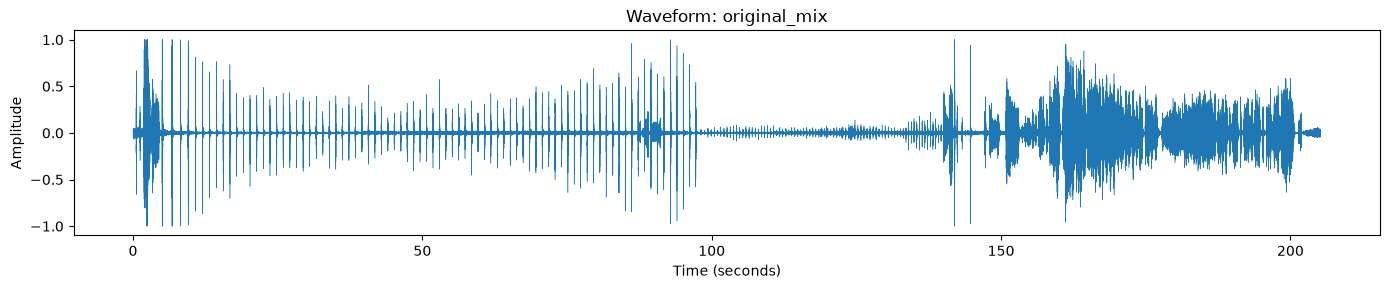

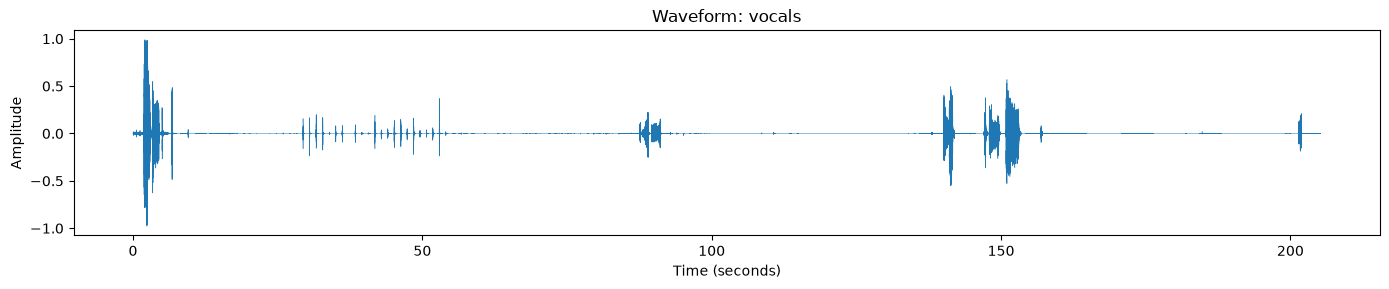

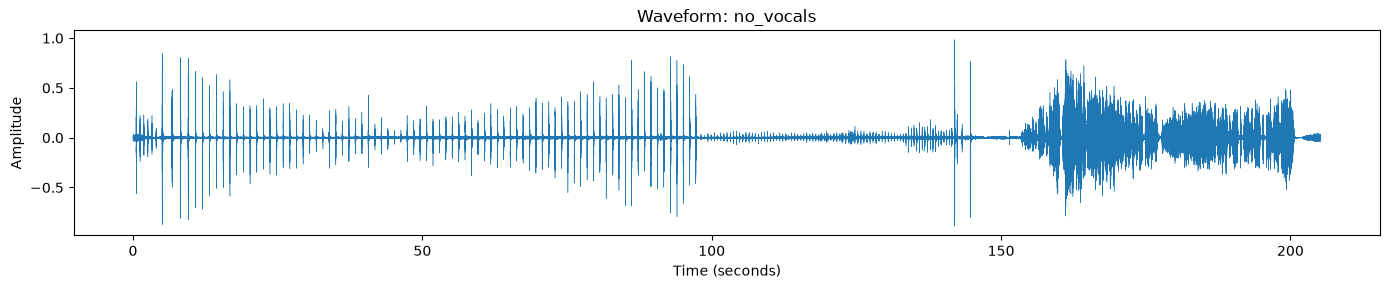

,stem,file,duration_seconds,sample_rate_hz,channels,frames,peak_absolute_amplitude,clipped_sample_fraction,rms_mean,near_silence_frame_fraction,near_silence_rms_threshold
0,original_mix,results/test_video/audio_original.wav,205.217959,44100,2,9050112,1.000000,0.000018,0.069106,0.000000,0.0001
1,vocals,results/test_video/demucs/htdemucs/audio_origi...,205.217959,44100,2,9050112,0.989960,0.000000,0.034986,0.644057,0.0001
2,no_vocals,results/test_video/demucs/htdemucs/audio_origi...,205.217959,44100,2,9050112,0.984711,0.000000,0.047825,0.000000,0.0001


In [6]:
import json
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt

audio_variants = {}
quality_rows = []
silence_threshold = 1e-4

for stem_name, stem_path in stem_paths.items():
    audio_info = sf.info(stem_path)
    y, sr = librosa.load(stem_path, sr=None, mono=True)
    duration_s = len(y) / sr
    peak = float(np.max(np.abs(y))) if len(y) else 0.0
    frame_rms = librosa.feature.rms(y=y)[0]
    silence_fraction = float(np.mean(frame_rms < silence_threshold)) if len(frame_rms) else 0.0
    quality = {
        "stem": stem_name,
        "file": str(stem_path.relative_to(PROJECT_ROOT)),
        "duration_seconds": duration_s,
        "sample_rate_hz": int(audio_info.samplerate),
        "channels": int(audio_info.channels),
        "frames": int(audio_info.frames),
        "peak_absolute_amplitude": peak,
        "clipped_sample_fraction": float(np.mean(np.abs(y) >= 0.999)) if len(y) else 0.0,
        "rms_mean": float(np.sqrt(np.mean(y ** 2))) if len(y) else 0.0,
        "near_silence_frame_fraction": silence_fraction,
        "near_silence_rms_threshold": silence_threshold,
    }
    (output_dir / f"audio_quality_{stem_name}.json").write_text(
        json.dumps(quality, ensure_ascii=False, indent=2), encoding="utf-8"
    )
    time = np.arange(len(y)) / sr
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(time, y, linewidth=0.35)
    ax.set(xlabel="Time (seconds)", ylabel="Amplitude", title=f"Waveform: {stem_name}")
    fig.tight_layout()
    fig.savefig(output_dir / f"audio_waveform_{stem_name}.png", dpi=150)
    plt.show()
    audio_variants[stem_name] = {"path": stem_path, "y": y, "sr": sr, "duration_s": duration_s}
    quality_rows.append(quality)

quality_df = pd.DataFrame(quality_rows)
display(quality_df)

## 基础向量化：三种音频版本分别计算

下面对原始混音、vocals、no_vocals 分别用 5 秒窗口、2.5 秒步长提取同一组可解释的声学特征；每行带有 stem 名称和片段起止时间，分别保存 CSV，并合并保存一份总表便于后续比较。

### 62 维的具体组成与选择依据

- 13 个 MFCC × 每个取均值和标准差 = **26 维**：概括频谱音色及窗口内变化。
- 12 个 chroma 音级类别各取均值 = **12 维**：概括音高类别/和声分布，不保留精确音符顺序。
- RMS（均值、标准差）= **2 维**：概括能量及动态变化。
- 谱质心、谱带宽、谱滚降、过零率（各均值、标准差）= **8 维**：概括频谱亮度/宽度、高频分布和波形变化。
- 7 个谱对比频带 × 每带均值和标准差 = **14 维**：概括不同频带的谱峰与谱谷差异。

总计 26 + 12 + 2 + 8 + 14 = **62 个数值特征**；起止时间与 stem 标签不计入特征维度。这是根据常见、容易解释和 librosa 可直接计算的音色、音高类别、能量与频谱特征选出的**试验基线**，不是通过本数据集训练或特征选择算法得出的最佳集合。旋律音符的先后顺序、精确节奏/乐句、语义都不在这 62 维里；后面的旋律分析会另存这些信息。

这只是**手工声学特征向量**，不是 CLAP 等预训练模型 embedding，也不代表主题/宣传标签。固定窗口适合先跑通流程；之后可把窗口替换为 VAD 或句子时间戳。短于 0.5 秒的尾段跳过，避免极短窗口导致特征不稳定。

该视频单独生成的向量只能描述本片段；要做跨视频相似性/聚类，需要对所有视频使用完全一致的特征和窗口策略。标准化参数应在整个比较语料上拟合，不要针对每个窗口单独标准化。三种版本的时间边界/时长若有微小差异，按各自实际音频长度记录。

In [7]:
window_seconds = 5.0
hop_seconds = 2.5
min_tail_seconds = 0.5
all_feature_frames = []

def summarize_feature(name, values, row):
    values = np.asarray(values, dtype=float)
    row[f"{name}_mean"] = float(np.mean(values))
    row[f"{name}_std"] = float(np.std(values))

for stem_name, variant in audio_variants.items():
    y = variant["y"]
    sr = variant["sr"]
    duration_s = variant["duration_s"]
    feature_rows = []
    for start_s in np.arange(0.0, duration_s, hop_seconds):
        end_s = min(start_s + window_seconds, duration_s)
        if end_s - start_s < min_tail_seconds:
            continue
        start_sample = int(round(start_s * sr))
        end_sample = min(int(round(end_s * sr)), len(y))
        segment = y[start_sample:end_sample]
        if len(segment) == 0:
            continue

        row = {"stem": stem_name, "start_seconds": float(start_s), "end_seconds": float(end_s)}
        mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=13)
        for i in range(mfcc.shape[0]):
            row[f"mfcc_{i + 1}_mean"] = float(np.mean(mfcc[i]))
            row[f"mfcc_{i + 1}_std"] = float(np.std(mfcc[i]))

        chroma = librosa.feature.chroma_stft(y=segment, sr=sr)
        for i in range(chroma.shape[0]):
            row[f"chroma_{i}"] = float(np.mean(chroma[i]))

        summarize_feature("rms", librosa.feature.rms(y=segment)[0], row)
        summarize_feature("spectral_centroid", librosa.feature.spectral_centroid(y=segment, sr=sr)[0], row)
        summarize_feature("spectral_bandwidth", librosa.feature.spectral_bandwidth(y=segment, sr=sr)[0], row)
        summarize_feature("spectral_rolloff", librosa.feature.spectral_rolloff(y=segment, sr=sr)[0], row)
        summarize_feature("zero_crossing_rate", librosa.feature.zero_crossing_rate(y=segment)[0], row)
        contrast = librosa.feature.spectral_contrast(y=segment, sr=sr)
        for i in range(contrast.shape[0]):
            row[f"spectral_contrast_{i}_mean"] = float(np.mean(contrast[i]))
            row[f"spectral_contrast_{i}_std"] = float(np.std(contrast[i]))
        feature_rows.append(row)

    stem_df = pd.DataFrame(feature_rows)
    stem_feature_path = output_dir / f"handcrafted_audio_vectors_{stem_name}.csv"
    stem_df.to_csv(stem_feature_path, index=False)
    all_feature_frames.append(stem_df)
    print(f"{stem_name}: {len(stem_df)} windows x {stem_df.shape[1] - 3} features -> {stem_feature_path}")

feature_df = pd.concat(all_feature_frames, ignore_index=True)
combined_feature_path = output_dir / "handcrafted_audio_vectors_all_stems.csv"
feature_df.to_csv(combined_feature_path, index=False)
print("Combined rows:", len(feature_df))
print("Feature dimensions (excluding stem and timestamps):", feature_df.shape[1] - 3)
print("Saved combined table:", combined_feature_path)
print(feature_df.groupby("stem").size())
print(feature_df.head().to_string(index=False))

original_mix: 82 windows x 62 features -> /home/ubuntu/music/results/test_video/handcrafted_audio_vectors_original_mix.csv
vocals: 82 windows x 62 features -> /home/ubuntu/music/results/test_video/handcrafted_audio_vectors_vocals.csv
no_vocals: 82 windows x 62 features -> /home/ubuntu/music/results/test_video/handcrafted_audio_vectors_no_vocals.csv
Combined rows: 246
Feature dimensions (excluding stem and timestamps): 62
Saved combined table: /home/ubuntu/music/results/test_video/handcrafted_audio_vectors_all_stems.csv
stem
no_vocals       82
original_mix    82
vocals          82
dtype: int64
        stem  start_seconds  end_seconds  mfcc_1_mean  mfcc_1_std  mfcc_2_mean  mfcc_2_std  mfcc_3_mean  mfcc_3_std  mfcc_4_mean  mfcc_4_std  mfcc_5_mean  mfcc_5_std  mfcc_6_mean  mfcc_6_std  mfcc_7_mean  mfcc_7_std  mfcc_8_mean  mfcc_8_std  mfcc_9_mean  mfcc_9_std  mfcc_10_mean  mfcc_10_std  mfcc_11_mean  mfcc_11_std  mfcc_12_mean  mfcc_12_std  mfcc_13_mean  mfcc_13_std  chroma_0  chroma_1  chrom

## 音乐分析：节拍、调性、音高类别、结构分段与序列对齐

以下复用 `youtube_audio_clustering_clean.ipynb` 中的 Librosa 音乐分析思路，对原始混音、vocals、no_vocals 分别处理：节拍与局部 BPM、CQT chroma/启发式大小调候选、5 秒音级时间线、chroma agglomerative 粗分段，并比较 stem 间的 chroma DTW 对齐。结果写入 `results/test_video/music_analysis/<stem>/`。调性与边界都是候选估计，不等于人工核实的乐谱或乐段标签。

注意：讲话、和弦、噪声和 Demucs 伪影都可能干扰音高/调性估计。chroma 显示音级类别分布，不是旋律转录；旋律音符转录见后续 Basic Pitch 单元。

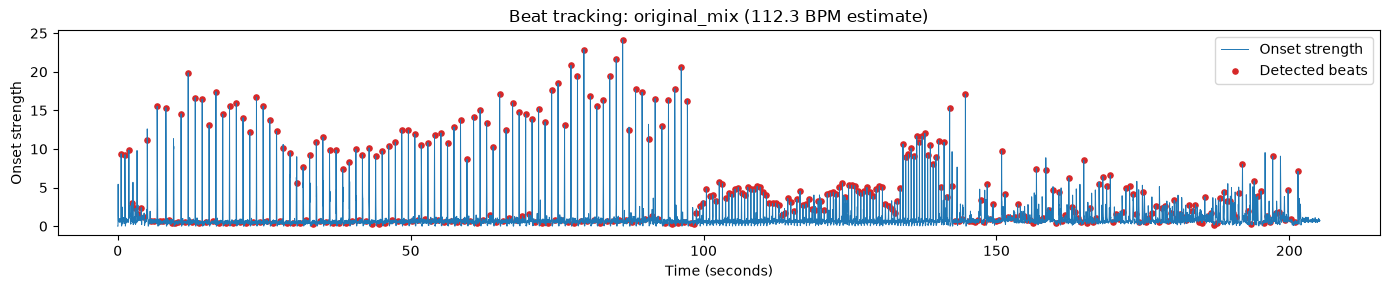

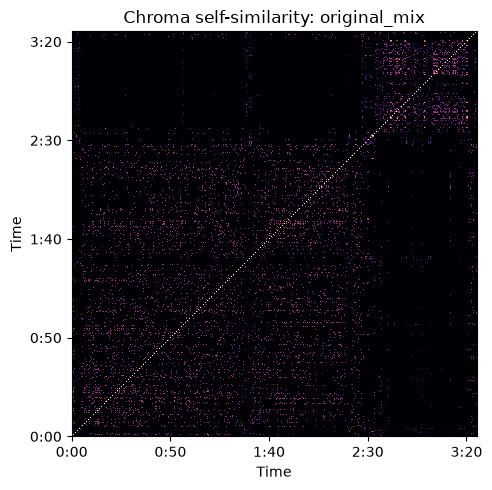

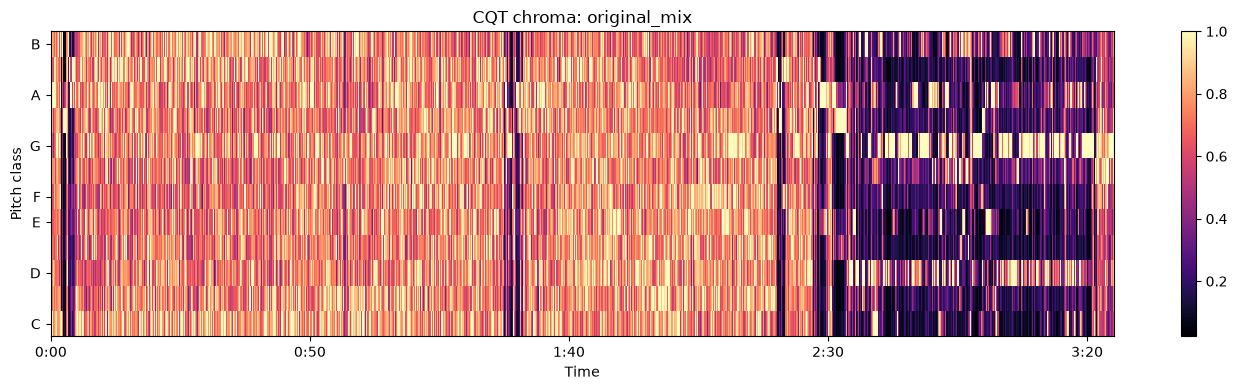

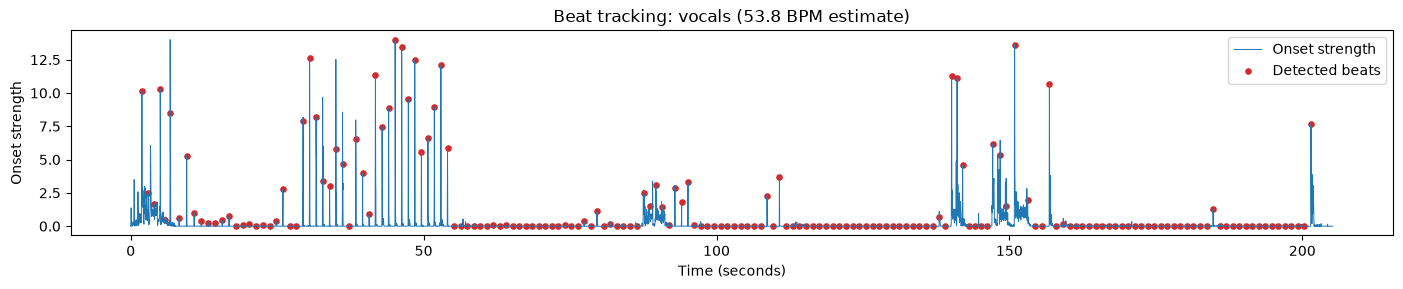

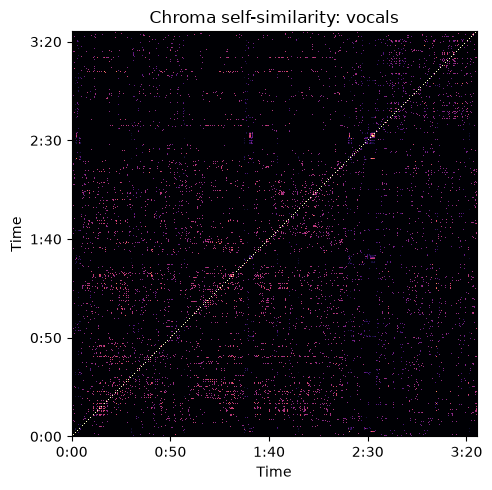

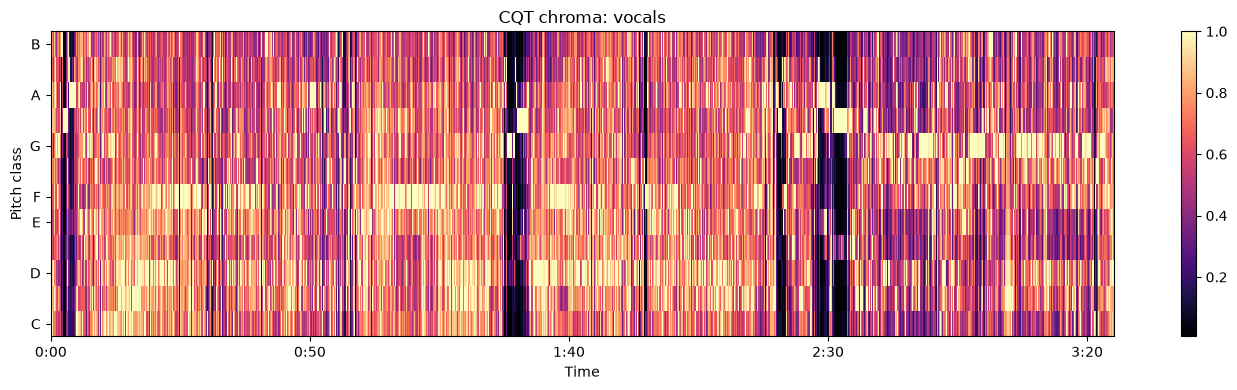

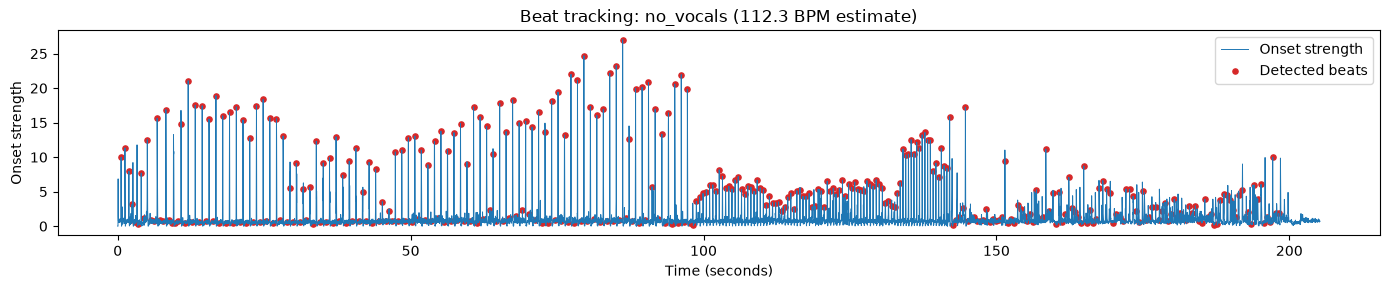

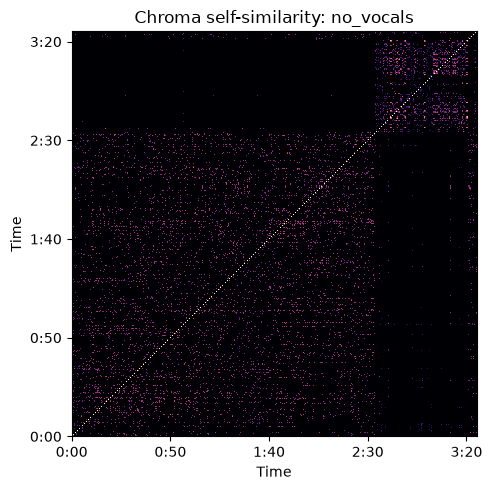

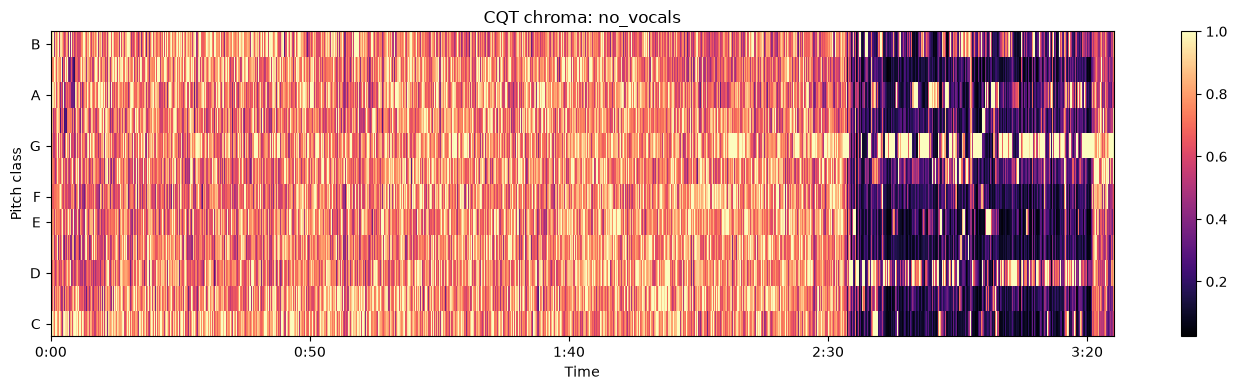

,stem,duration_seconds,estimated_tempo_bpm,detected_beats,top_key_candidate,top_key_correlation,top_key_margin,candidate_boundaries
0,original_mix,205.217959,112.347147,372,G:maj,0.897146,0.188010,8
1,vocals,205.217959,53.833008,179,D:min,0.526140,0.226535,8
2,no_vocals,205.217959,112.347147,366,G:maj,0.938784,0.273374,8


,reference,candidate,normalized_dtw_cost
0,original_mix,vocals,0.055962
1,original_mix,no_vocals,0.014779


Saved music analysis to: /home/ubuntu/music/results/test_video/music_analysis


In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import display

music_out_dir = output_dir / "music_analysis"
music_out_dir.mkdir(parents=True, exist_ok=True)
analysis_sr = 22050
chroma_hop = 2048
pitch_classes = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
major_template = np.array([6.35, 2.23, 3.48, 2.33, 4.38, 4.09, 2.52, 5.19, 2.39, 3.66, 2.29, 2.88])
minor_template = np.array([6.33, 2.68, 3.52, 5.38, 2.60, 3.53, 2.54, 4.75, 3.98, 2.69, 3.34, 3.17])
chroma_by_stem = {}
music_summary_rows = []

for stem_name, variant in audio_variants.items():
    y, sr = librosa.load(variant["path"], sr=analysis_sr, mono=True)
    stem_dir = music_out_dir / stem_name
    stem_dir.mkdir(parents=True, exist_ok=True)
    duration_s = len(y) / sr

    # Beat tracking, plus intervals between detected beats as a local tempo cue.
    beat_hop = 512
    onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=beat_hop)
    tempo, beat_frames = librosa.beat.beat_track(
        onset_envelope=onset_env, sr=sr, hop_length=beat_hop, units="frames"
    )
    beat_times = librosa.frames_to_time(beat_frames, sr=sr, hop_length=beat_hop)
    tempo_bpm = float(np.asarray(tempo).reshape(-1)[0])
    beat_intervals = np.diff(beat_times)
    local_bpm = np.divide(
        60.0, beat_intervals, out=np.full(beat_intervals.shape, np.nan), where=beat_intervals > 0
    )
    beat_df = pd.DataFrame({
        "beat_number": np.arange(1, len(beat_times) + 1),
        "time_seconds": beat_times,
        "interval_from_previous_seconds": np.r_[np.nan, beat_intervals],
        "local_bpm": np.r_[np.nan, local_bpm],
    })
    beat_df.to_csv(stem_dir / "beat_times.csv", index=False)
    onset_times = librosa.frames_to_time(np.arange(len(onset_env)), sr=sr, hop_length=beat_hop)
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(onset_times, onset_env, linewidth=0.7, label="Onset strength")
    if len(beat_times):
        ax.scatter(beat_times, np.interp(beat_times, onset_times, onset_env), s=14, color="tab:red", label="Detected beats")
    ax.set(title=f"Beat tracking: {stem_name} ({tempo_bpm:.1f} BPM estimate)", xlabel="Time (seconds)", ylabel="Onset strength")
    ax.legend()
    fig.tight_layout()
    fig.savefig(stem_dir / "beat_tracking.png", dpi=140)
    plt.show()

    # Chroma profile, heuristic key candidates, and five-second pitch-class timeline.
    chroma = librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=chroma_hop)
    chroma_by_stem[stem_name] = chroma
    chroma_profile = chroma.mean(axis=1)
    key_rows = []
    for mode, template in [("maj", major_template), ("min", minor_template)]:
        for tonic_index, tonic in enumerate(pitch_classes):
            correlation = np.corrcoef(chroma_profile, np.roll(template, tonic_index))[0, 1]
            key_rows.append({
                "key": f"{tonic}:{mode}", "tonic": tonic, "mode": mode,
                "profile_correlation": float(correlation),
            })
    key_df = pd.DataFrame(key_rows).sort_values("profile_correlation", ascending=False).reset_index(drop=True)
    key_df.to_csv(stem_dir / "key_candidates.csv", index=False)
    pd.DataFrame({"pitch_class": pitch_classes, "mean_chroma": chroma_profile}).to_csv(
        stem_dir / "chroma_profile.csv", index=False
    )
    frame_times = librosa.frames_to_time(np.arange(chroma.shape[1]), sr=sr, hop_length=chroma_hop)
    window_ids = np.floor(frame_times / 5.0).astype(int)
    timeline_rows = []
    for window_id in np.unique(window_ids):
        in_window = window_ids == window_id
        window_chroma = chroma[:, in_window]
        dominant_index = int(window_chroma.mean(axis=1).argmax())
        timeline_rows.append({
            "start_seconds": float(window_id * 5.0),
            "end_seconds": float(min((window_id + 1) * 5.0, duration_s)),
            "dominant_pitch_class": pitch_classes[dominant_index],
            "mean_chroma": float(window_chroma[dominant_index].mean()),
        })
    pd.DataFrame(timeline_rows).to_csv(stem_dir / "pitch_class_timeline_5s.csv", index=False)

    # Coarse chroma-based boundaries, with a complete interval table including audio end.
    n_frames = chroma.shape[1]
    boundary_frames = librosa.segment.agglomerative(chroma, k=min(8, n_frames))
    candidate_times = librosa.frames_to_time(boundary_frames, sr=sr, hop_length=chroma_hop)
    pd.DataFrame({"boundary_frame": boundary_frames, "time_seconds": candidate_times}).to_csv(
        stem_dir / "candidate_segment_boundaries.csv", index=False
    )
    interval_frames = np.unique(np.r_[0, boundary_frames, n_frames])
    interval_times = librosa.frames_to_time(interval_frames, sr=sr, hop_length=chroma_hop)
    interval_times[0] = 0.0
    interval_times[-1] = duration_s
    pd.DataFrame({
        "segment_id": np.arange(1, len(interval_times)),
        "start_seconds": interval_times[:-1],
        "end_seconds": interval_times[1:],
    }).to_csv(stem_dir / "candidate_segment_intervals.csv", index=False)
    recurrence = librosa.segment.recurrence_matrix(chroma, mode="affinity", self=True, width=3)
    fig, ax = plt.subplots(figsize=(6, 5))
    librosa.display.specshow(recurrence, x_axis="time", y_axis="time", sr=sr, hop_length=chroma_hop, cmap="magma", ax=ax)
    ax.set_title(f"Chroma self-similarity: {stem_name}")
    fig.tight_layout()
    fig.savefig(stem_dir / "recurrence_matrix.png", dpi=140)
    plt.show()

    # Save a compact chroma plot for visual review.
    fig, ax = plt.subplots(figsize=(14, 4))
    img = librosa.display.specshow(chroma, x_axis="time", y_axis="chroma", sr=sr, hop_length=chroma_hop, ax=ax)
    ax.set_title(f"CQT chroma: {stem_name}")
    fig.colorbar(img, ax=ax)
    fig.tight_layout()
    fig.savefig(stem_dir / "chroma_timeline.png", dpi=140)
    plt.show()

    best = key_df.iloc[0]
    margin = float(best["profile_correlation"] - key_df.iloc[1]["profile_correlation"])
    music_summary_rows.append({
        "stem": stem_name, "duration_seconds": duration_s, "estimated_tempo_bpm": tempo_bpm,
        "detected_beats": len(beat_times), "top_key_candidate": best["key"],
        "top_key_correlation": float(best["profile_correlation"]), "top_key_margin": margin,
        "candidate_boundaries": len(boundary_frames),
    })

music_summary = pd.DataFrame(music_summary_rows)
music_summary.to_csv(music_out_dir / "music_summary.csv", index=False)
display(music_summary)

# Compare original mix with each Demucs stem using normalized chroma DTW.
alignment_rows = []
reference_name = "original_mix"
for candidate_name in ["vocals", "no_vocals"]:
    X = librosa.util.normalize(chroma_by_stem[reference_name], axis=0)
    Y = librosa.util.normalize(chroma_by_stem[candidate_name], axis=0)
    D, wp = librosa.sequence.dtw(X=X, Y=Y, metric="cosine")
    alignment_cost = float(D[-1, -1] / max(len(wp), 1))
    alignment_df = pd.DataFrame({
        "original_frame": wp[::-1, 0], "candidate_frame": wp[::-1, 1],
        "original_time_seconds": librosa.frames_to_time(wp[::-1, 0], sr=analysis_sr, hop_length=chroma_hop),
        "candidate_time_seconds": librosa.frames_to_time(wp[::-1, 1], sr=analysis_sr, hop_length=chroma_hop),
    })
    alignment_df.to_csv(music_out_dir / f"dtw_original_vs_{candidate_name}.csv", index=False)
    alignment_rows.append({"reference": reference_name, "candidate": candidate_name, "normalized_dtw_cost": alignment_cost})
pd.DataFrame(alignment_rows).to_csv(music_out_dir / "dtw_summary.csv", index=False)
display(pd.DataFrame(alignment_rows))
print("Saved music analysis to:", music_out_dir)

## 音乐预训练 embedding：MERT-v1-95M（首次运行会下载模型）

MERT 是音乐音频理解模型；与 62 维手工特征不同，它会为音频片段产生 learned embedding，用于比较音乐片段的整体表示相似性。模型卡说明该 checkpoint 使用 **24 kHz** 输入、预训练上下文为 **5 秒**。下面按 5 秒窗、2.5 秒步长处理三种 stem；末尾不足 5 秒的片段补零到 5 秒，同时保留实际片段结束时间和补零长度。

第一次执行模型加载代码会从 Hugging Face 下载 `m-a-p/MERT-v1-95M` 的代码/权重，文件可能较大；需要网络、足够磁盘与内存。该模型要求 `trust_remote_code=True`，表示 Transformers 会执行模型仓库提供的自定义代码；运行前请先确认仓库来源、代码、模型许可及适合你的环境。需要的包：`transformers`（以及兼容的 PyTorch；项目环境已有 torch）。若缺少 transformers，先在当前 kernel 用 `%pip install -U transformers`，然后重启 kernel 并从头运行前面的单元。

每段向量取最后一层 hidden states 在时间帧上的平均值（mean pooling），并保存到 `.npy`；相应行号、stem、起止时间、实际/补零时长写入索引 CSV。该 pooling 是方便比较的基线，不是模型唯一或必然最佳的表示。

In [11]:
import numpy as np
import pandas as pd
import torch
import librosa
from transformers import AutoModel, Wav2Vec2FeatureExtractor

MERT_MODEL_ID = "m-a-p/MERT-v1-95M"
mert_processor = Wav2Vec2FeatureExtractor.from_pretrained(
    MERT_MODEL_ID, trust_remote_code=True
)
mert_model = AutoModel.from_pretrained(
    MERT_MODEL_ID, trust_remote_code=True
)
mert_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mert_model = mert_model.to(mert_device).eval()
mert_sr = int(mert_processor.sampling_rate)
mert_window_seconds = 5.0
mert_hop_seconds = 2.5
mert_min_tail_seconds = 0.5
mert_out_dir = output_dir / "music_analysis" / "mert"
mert_out_dir.mkdir(parents=True, exist_ok=True)
manifest_path = output_dir / "audio_manifest.csv"
if not manifest_path.is_file():
    raise FileNotFoundError(
        f"Audio manifest not found: {manifest_path}. Run the manifest cell first."
    )
manifest_df = pd.read_csv(manifest_path)
required_manifest_columns = {"video_id", "audio_variant"}
if not required_manifest_columns.issubset(manifest_df.columns):
    raise ValueError(f"Manifest must include columns: {sorted(required_manifest_columns)}")
mert_vectors = []
mert_index_rows = []
mert_row = 0

for stem_name, variant in audio_variants.items():
    source_y = variant["y"]
    source_sr = int(variant["sr"])
    y_24k = librosa.resample(source_y, orig_sr=source_sr, target_sr=mert_sr)
    duration_s = len(source_y) / source_sr
    window_samples = int(round(mert_window_seconds * mert_sr))

    for start_s in np.arange(0.0, duration_s, mert_hop_seconds):
        end_s = min(start_s + mert_window_seconds, duration_s)
        actual_duration_s = end_s - start_s
        if actual_duration_s < mert_min_tail_seconds:
            continue
        start_sample = int(round(start_s * mert_sr))
        end_sample = min(int(round(end_s * mert_sr)), len(y_24k))
        segment = y_24k[start_sample:end_sample].astype(np.float32, copy=False)
        padded_samples = max(0, window_samples - len(segment))
        if padded_samples:
            segment = np.pad(segment, (0, padded_samples))

        inputs = mert_processor(
            segment, sampling_rate=mert_sr, return_tensors="pt"
        )
        inputs = {key: value.to(mert_device) for key, value in inputs.items()}
        with torch.inference_mode():
            outputs = mert_model(**inputs)
            hidden_state = getattr(outputs, "last_hidden_state", None)
            if hidden_state is None:
                all_hidden_states = getattr(outputs, "hidden_states", None)
                if not all_hidden_states:
                    raise RuntimeError(
                        "MERT returned neither last_hidden_state nor hidden_states; "
                        "inspect the model output/API before continuing."
                    )
                hidden_state = all_hidden_states[-1]
            vector = hidden_state.mean(dim=1).squeeze(0).cpu().numpy()

        mert_vectors.append(vector.astype(np.float32))
        mert_index_rows.append({
            "embedding_row": mert_row,
            "video_id": manifest_df.loc[manifest_df["audio_variant"] == stem_name, "video_id"].iloc[0],
            "stem": stem_name,
            "start_seconds": float(start_s),
            "end_seconds": float(end_s),
            "actual_duration_seconds": float(actual_duration_s),
            "padded_duration_seconds": float(padded_samples / mert_sr),
            "model_id": MERT_MODEL_ID,
            "sample_rate_hz": mert_sr,
            "pooling": "last_hidden_state_mean_over_time",
        })
        mert_row += 1

mert_matrix = np.stack(mert_vectors)
mert_matrix_path = mert_out_dir / "mert_v1_95m_embeddings.npy"
mert_index_path = mert_out_dir / "mert_v1_95m_embedding_index.csv"
np.save(mert_matrix_path, mert_matrix)
mert_index_df = pd.DataFrame(mert_index_rows)
mert_index_df.to_csv(mert_index_path, index=False)
print("Device:", mert_device)
print("Model sample rate:", mert_sr)
print("Embedding matrix shape:", mert_matrix.shape)
print("Saved vectors:", mert_matrix_path)
print("Saved row mapping:", mert_index_path)
print(mert_index_df.groupby("stem").size())

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Device: cuda
Model sample rate: 24000
Embedding matrix shape: (246, 768)
Saved vectors: /home/ubuntu/music/results/test_video/music_analysis/mert/mert_v1_95m_embeddings.npy
Saved row mapping: /home/ubuntu/music/results/test_video/music_analysis/mert/mert_v1_95m_embedding_index.csv
stem
no_vocals       82
original_mix    82
vocals          82
dtype: int64


### CLAP 示例：用文字描述检索/比较声音（示例分数，不是本视频实测）

CLAP 把音频和文字描述映射到共同向量空间，可用来问“这个音频片段与哪些描述更相似？”例如对同一 5 秒片段比较这些候选描述：

- `A ceremonial brass band playing a slow march.`（仪式性铜管乐队演奏缓慢进行曲）
- `A choir singing with orchestral accompaniment.`（合唱团在管弦乐伴奏下演唱）
- `A crowd applauding and cheering outdoors.`（户外人群鼓掌欢呼）
- `A person speaking over background music.`（有人在背景音乐上讲话）

CLAP 会为每段音频和每条文字描述计算相似度；如果第一条分数最高，只能说模型在这组候选里认为该片段更像“铜管进行曲”的描述。分数依赖模型、语言、片段、提示词措辞和候选集合；这**不是**事件确认、音乐转录、政治/宣传分类，也不能说明候选列表以外不存在其他内容。下面只是说明用途的示例，数值不是真实输出。

## Basic Pitch：音符事件 / MIDI 旋律转录（独立环境）

clean notebook 使用 Basic Pitch CLI 对 vocals stem 生成音符事件 CSV 和 MIDI。此处扩展为可分别尝试三种版本。Basic Pitch 更偏向音符/多音高转录，不保证在讲话、合唱、混合现场声或 Demucs 伪影上准确；先把结果当候选音符并试听/检查 MIDI。若三种输入都运行会比较耗时，也可先改 `basic_pitch_stems` 只跑 vocals 或你听起来音乐最清楚的版本。

已有项目中 CLI 位于 `~/venvs/basic-pitch/bin/basic-pitch`。如果文件不存在，此代码会明确报错；请先在其兼容环境安装/配置 Basic Pitch，不要假设它已安装在当前 notebook kernel。输出到每个 stem 单独的子目录以避免覆盖。

In [12]:
import subprocess

basic_pitch_cli = Path.home() / "venvs" / "basic-pitch" / "bin" / "basic-pitch"
if not basic_pitch_cli.is_file():
    raise FileNotFoundError(f"Basic Pitch CLI not found: {basic_pitch_cli}")

basic_pitch_stems = ["original_mix", "vocals", "no_vocals"]
basic_pitch_root = output_dir / "basic_pitch"
for stem_name in basic_pitch_stems:
    stem_output = basic_pitch_root / stem_name
    stem_output.mkdir(parents=True, exist_ok=True)
    subprocess.run([
        str(basic_pitch_cli), "--save-midi", "--save-note-events",
        str(stem_output), str(stem_paths[stem_name]),
    ], check=True)
    print(f"Basic Pitch completed: {stem_name} -> {stem_output}")

2026-10-03 01:40:06.290788: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-10-03 01:40:06.344751: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-10-03 01:40:06.344795: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-10-03 01:40:06.346127: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-10-03 01:40:06.354948: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-10-03 01:40:06.355223: I tensorflow/core/platform/cpu_feature_guard.cc:1


✨✨✨✨✨✨✨✨✨
✨ Basic Pitch  ✨
✨✨✨✨✨✨✨✨✨

Importing the ML infrence library (this may take a few seconds)...


2026-10-03 01:40:12.090938: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



Predicting MIDI for /home/ubuntu/music/results/test_video/audio_original.wav...


  Creating midi...
  💅 Saved to /home/ubuntu/music/results/test_video/basic_pitch/original_mix/audio_original_basic_pitch.mid


  Creating note events...
  🌸 Saved to /home/ubuntu/music/results/test_video/basic_pitch/original_mix/audio_original_basic_pitch.csv

✨ Done ✨

Basic Pitch completed: original_mix -> /home/ubuntu/music/results/test_video/basic_pitch/original_mix


2026-10-03 01:40:22.506607: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-10-03 01:40:22.559427: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-10-03 01:40:22.559493: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-10-03 01:40:22.560737: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-10-03 01:40:22.569063: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-10-03 01:40:22.569330: I tensorflow/core/platform/cpu_feature_guard.cc:1

...


Predicting MIDI for /home/ubuntu/music/results/test_video/demucs/htdemucs/audio_original/vocals.wav...


  Creating midi...
  💅 Saved to /home/ubuntu/music/results/test_video/basic_pitch/vocals/vocals_basic_pitch.mid


  Creating note events...
  🌸 Saved to /home/ubuntu/music/results/test_video/basic_pitch/vocals/vocals_basic_pitch.csv

✨ Done ✨

Basic Pitch completed: vocals -> /home/ubuntu/music/results/test_video/basic_pitch/vocals


2026-10-03 01:40:37.856786: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-10-03 01:40:37.910370: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-10-03 01:40:37.910426: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-10-03 01:40:37.911652: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-10-03 01:40:37.919893: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-10-03 01:40:37.920152: I tensorflow/core/platform/cpu_feature_guard.cc:1


✨✨✨✨✨✨✨✨✨
✨ Basic Pitch  ✨
✨✨✨✨✨✨✨✨✨

Importing the ML infrence library (this may take a few seconds)...


2026-10-03 01:40:42.589730: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



Predicting MIDI for /home/ubuntu/music/results/test_video/demucs/htdemucs/audio_original/no_vocals.wav...


  Creating midi...
  💅 Saved to /home/ubuntu/music/results/test_video/basic_pitch/no_vocals/no_vocals_basic_pitch.mid


  Creating note events...
  🌸 Saved to /home/ubuntu/music/results/test_video/basic_pitch/no_vocals/no_vocals_basic_pitch.csv

✨ Done ✨

Basic Pitch completed: no_vocals -> /home/ubuntu/music/results/test_video/basic_pitch/no_vocals


## 预训练 embedding 与其他尚未完成的步骤

### 已完成（本次单视频试验）

- 音轨提取、Demucs `original_mix` / `vocals` / `no_vocals` 三版本、质量检查、manifest 和三版本手工特征向量。
- Librosa 音乐分析：三版本节拍/chroma/调性候选/粗结构分段，原始音频与 stems 的 DTW 对齐。
- MERT-v1-95M：已生成 246 × 768 的窗口 embedding（每 stem 82 个窗口）及时间索引。
- Basic Pitch：三版本均已生成 MIDI 和 note-event CSV；需人工试听核验音符转录。

### 尚未完成

- **MERT embedding 的解释/评估：** 向量已生成，但还没有做相似片段检索、相似度质量核验、与手工特征对照或聚类。先抽听近邻片段，再决定是否适合当前音乐相似性任务。
- **CLAP：** 尚未生成。可作为音频与文字声音描述的相似度探索（如“鼓乐/合唱/管弦乐”），不是专门的旋律转录模型或主题真值。
- **YAMNet/PANNs：** 尚未运行；它们适合宽泛声音事件候选（人群、掌声、音乐等），不是旋律/调性分析核心。
- **VAD/ASR：** 尚未运行；如果此次目标只研究音乐，可暂缓。只有需要定位讲话或分析歌词/口号时再加。
- **跨视频聚类：** 尚未运行；当前只有一个视频，82 个重叠窗口彼此相关，不是 82 个独立视频样本。积累多条可比视频后，再按同一窗口/模型生成向量、在语料级标准化，再试 UMAP 可视化和 HDBSCAN/KMeans 等聚类，并试听代表片段。

预训练 embedding 与前面 62 维手工向量回答的问题不完全相同：手工特征是可解释的具体声学统计；预训练 embedding 是模型从大量训练音频学到的压缩表示，维度和相似性由模型决定。任何聚类都只代表该向量空间中的相似性，不能单独证明音乐主题或含义。

## 分析记录表建议字段

`video_id`, `source`, `search_query`, `retrieved_at`, `stem` (`original_mix` / `vocals` / `no_vocals`), `start_time`, `end_time`, `transcript`, `asr_model`, `asr_confidence`, `vad_speech_probability`, `sound_event_candidates`, `text_embedding_path`, `audio_embedding_path`, `quality_flags`, `human_notes`, `uncertainty`。

本样本搜索词记录为 `国庆`。发现样本的搜索条件本身会影响语料，因此后续要同时记录其他搜索词/来源和纳入规则，避免把搜索结果误当作平台整体内容的代表。